In [1]:
import requests
import pandas as pd
from datetime import datetime
import os

In [3]:
# Obtener concursos
url = "https://codeforces.com/api/contest.list"
response = requests.get(url)
data = response.json()
# Revisar si está bien
if data["status"] == "OK":
    contests = data["result"]
print(f"Se encontraron {len(contests)} concursos.")

Se encontraron 1996 concursos.


In [5]:
# Mostramos los primeros 20 nombres como prueba
for c in contests[:20]:
        print(f"- {c['name']}")

- Codeforces Round (Div. 1)
- Codeforces Round (Div. 2)
- Codeforces Round (Div. 1)
- Codeforces Round (Div. 2)
- Educational Codeforces Round 178 (Rated for Div. 2)
- Codeforces Round (Div. 1)
- Codeforces Round (Div. 2)
- Codeforces Round 1019 (Div. 2)
- Tact Smart Battle 1
- Neowise Labs Contest 1 (Codeforces Round 1018, Div. 1 + Div. 2)
- Codeforces Round 1017 (Div. 4)
- Codeforces Round 1016 (Div. 3)
- Kotlin Heroes: Episode 12
- Teza Round 1 (Codeforces Round 1015, Div. 1 + Div. 2)
- Educational Codeforces Round 177 (Rated for Div. 2)
- April Fools Day Contest 2025
- Kotlin Heroes: Practice 12
- Codeforces Round 1014 (Div. 2)
- Codeforces Round 1013 (Div. 3)
- Codeforces Round 1012 (Div. 1)


In [7]:
# Importar datetime 
from datetime import datetime

# Filtrar los concursos relevantes, concursos no activos y que contengan fecha de inicio
filtered = []
for contest in contests:
    if contest["phase"] != "FINISHED":
        continue
    if "startTimeSeconds" not in contest:
        continue
        
    date = datetime.utcfromtimestamp(contest["startTimeSeconds"])
    if datetime(2024, 7, 1) <= date <= datetime(2024, 12, 31):
        if any(word in contest["name"] for word in ["Hello", "Round", "Good Bye"]):
            filtered.append({
                "id": contest["id"],
                "name": contest["name"],
                "start_time": date,
                "duration": contest["durationSeconds"]
            })

# Mostrar los resultados
for c in filtered:
    print(f"{c['id']} - {c['name']} - {c['start_time']}")

2053 - Good Bye 2024: 2025 is NEAR - 2024-12-28 14:35:00
2043 - Educational Codeforces Round 173 (Rated for Div. 2) - 2024-12-24 14:35:00
2051 - Codeforces Round 995 (Div. 3) - 2024-12-22 14:35:00
2049 - Codeforces Round 994 (Div. 2) - 2024-12-20 14:35:00
2048 - Codeforces Global Round 28 - 2024-12-19 14:35:00
2044 - Codeforces Round 993 (Div. 4) - 2024-12-15 14:35:00
2040 - Codeforces Round 992 (Div. 2) - 2024-12-08 14:35:00
2050 - Codeforces Round 991 (Div. 3) - 2024-12-05 14:35:00
2046 - Codeforces Round 990 (Div. 1) - 2024-12-03 06:25:00
2047 - Codeforces Round 990 (Div. 2) - 2024-12-03 06:25:00
2042 - Educational Codeforces Round 172 (Rated for Div. 2) - 2024-12-02 14:35:00
2034 - Rayan Programming Contest 2024 - Selection (Codeforces Round 989, Div. 1 + Div. 2) - 2024-11-30 14:35:00
2039 - CodeTON Round 9 (Div. 1 + Div. 2, Rated, Prizes!) - 2024-11-23 14:35:00
2037 - Codeforces Round 988 (Div. 3) - 2024-11-17 14:35:00
2031 - Codeforces Round 987 (Div. 2) - 2024-11-15 12:35:00
202

In [11]:
import os
import requests
import json
from datetime import datetime

base_url = "https://codeforces.com/api"

# Función segura para obtener JSON
def safe_get_json(url):
    try:
        response = requests.get(url)
        if response.status_code != 200:
            print(f"❌ HTTP {response.status_code} - {url}")
            return None
        if not response.text.strip():
            print(f"⚠️ Respuesta vacía - {url}")
            return None
        data = response.json()
        if data.get("status") != "OK":
            print(f"⚠️ Respuesta con error en status - {url} - Status: {data.get('status')}")
            return None
        return data
    except Exception as e:
        print(f"❌ Error procesando {url}: {e}")
        return None

# Función para guardar JSON
def save_json(data, filename):
    try:
        with open(filename, 'w', encoding='utf-8') as f:
            json.dump(data, f, indent=2, ensure_ascii=False)
    except Exception as e:
        print(f"❌ Error guardando {filename}: {e}")

# Obtener información de cada concurso con standings y problemas
def get_contest_details(contest_id):
    url = f"{base_url}/contest.standings?contestId={contest_id}&from=1&count=1"
    res = safe_get_json(url)
    if res is None:
        print(f"⚠️ Falló standings para contest {contest_id}")
        return None, None
    return res["result"]["contest"], res["result"]["problems"]

# Definir el rango de fechas (julio a diciembre de 2024)
start_date = datetime(2024, 7, 1)
end_date = datetime(2024, 12, 31)

# Palabras clave permitidas en los títulos
allowed_keywords = ["Hello", "Round", "Good Bye"]

# Obtener lista de concursos
contests_data = safe_get_json(f"{base_url}/contest.list")

total = 0
aceptados = 0

if contests_data and 'result' in contests_data:
    print(f"🎯 Total de concursos encontrados: {len(contests_data['result'])}")
    for contest in contests_data['result']:
        total += 1
        contest_id = contest.get('id')
        title = contest.get('name', 'Sin título')

        # Filtro 1: fase terminada
        if contest.get('phase') != 'FINISHED':
            print(f"⏭️ {contest_id} omitido (no terminado): {title}")
            continue

        # Filtro 2: fechas
        contest_start_time = datetime.utcfromtimestamp(contest['startTimeSeconds'])
        if not (start_date <= contest_start_time <= end_date):
            print(f"⏭️ {contest_id} omitido (fuera de fecha): {contest_start_time.date()} - {title}")
            continue

        # Filtro 3: palabras clave
        if not any(keyword in title for keyword in allowed_keywords):
            print(f"⏭️ {contest_id} omitido (sin keyword válida): {title}")
            continue

        # Si pasa todos los filtros
        aceptados += 1
        print(f"✅ {contest_id} aceptado: {title} - {contest_start_time.date()}")

        folder = f"contest_{contest_id}"
        if os.path.exists(folder):
            print(f"🔁 Carpeta ya existe, se omite: {folder}")
            continue

        try:
            os.makedirs(folder, exist_ok=True)
            print(f"📁 Creando carpeta: {folder}")

            # Obtener info del concurso y problemas (standings con count=1)
            contest_info, problems = get_contest_details(contest_id)
            if contest_info:
                save_json(contest_info, os.path.join(folder, "contest_info.json"))
            if problems:
                save_json(problems, os.path.join(folder, "problems.json"))

            # Obtener standings (5 primeros para muestra)
            standings_url = f"{base_url}/contest.standings?contestId={contest_id}&from=1&count=5"
            standings = safe_get_json(standings_url)
            if standings:
                save_json(standings, os.path.join(folder, "standings.json"))

            # Obtener submissions (limitado a 1000)
            submissions_url = f"{base_url}/contest.status?contestId={contest_id}&from=1&count=1000"
            submissions = safe_get_json(submissions_url)
            if submissions:
                save_json(submissions, os.path.join(folder, "submissions.json"))

            # Obtener rating changes
            rating_url = f"{base_url}/contest.ratingChanges?contestId={contest_id}"
            rating = safe_get_json(rating_url)
            if rating:
                save_json(rating, os.path.join(folder, "rating_changes.json"))
            else:
                save_json(
                    {"note": "Este concurso no tuvo cambios de rating o aún no están disponibles."},
                    os.path.join(folder, "rating_changes.json")
                )
                print(f"⚠️ No hay rating changes para contest {contest_id}, se guardó nota informativa.")

            print(f"✅ Datos guardados para contest {contest_id}\n")

        except Exception as e:
            print(f"❌ Error general con contest {contest_id}: {e}\n")

    print(f"📊 Revisión completa: {total} concursos revisados, {aceptados} aceptados.\n")
else:
    print("🚫 No se pudo obtener la lista de concursos.")

🎯 Total de concursos encontrados: 1996
⏭️ 2101 omitido (no terminado): Codeforces Round (Div. 1)
⏭️ 2102 omitido (no terminado): Codeforces Round (Div. 2)
⏭️ 2099 omitido (no terminado): Codeforces Round (Div. 1)
⏭️ 2100 omitido (no terminado): Codeforces Round (Div. 2)
⏭️ 2104 omitido (no terminado): Educational Codeforces Round 178 (Rated for Div. 2)
⏭️ 2097 omitido (no terminado): Codeforces Round (Div. 1)
⏭️ 2098 omitido (no terminado): Codeforces Round (Div. 2)
⏭️ 2103 omitido (no terminado): Codeforces Round 1019 (Div. 2)
⏭️ 2105 omitido (no terminado): Tact Smart Battle 1
⏭️ 2096 omitido (no terminado): Neowise Labs Contest 1 (Codeforces Round 1018, Div. 1 + Div. 2)
⏭️ 2094 omitido (fuera de fecha): 2025-04-13 - Codeforces Round 1017 (Div. 4)
⏭️ 2093 omitido (fuera de fecha): 2025-04-08 - Codeforces Round 1016 (Div. 3)
⏭️ 2087 omitido (fuera de fecha): 2025-04-07 - Kotlin Heroes: Episode 12
⏭️ 2084 omitido (fuera de fecha): 2025-04-05 - Teza Round 1 (Codeforces Round 1015, Div. 

In [12]:
#De contest_info.json
#id: Identificador único del concurso.
#name: Nombre o título del concurso.
#durationSeconds: Duración del concurso en segundos.
#startTimeSeconds: Momento en que comenzó el concurso (formato timestamp UTC).

#De problems.json
#index: Identificador del problema (por ejemplo, A, B, C).
#name: Título del problema.
#points: Puntos posibles para ese problema.
#tags: Etiquetas relacionadas a los temas o técnicas del problema.

#De standings.json
#problems: Lista de problemas del concurso (coincide con problems.json).
#rows: Resultados individuales para los usuarios listados.
#party.members[0].handle: Nombre de usuario del participante.
#rank: Posición final en la tabla.
#successfulHackCount: Número de hacks exitosos realizados.
#problemResults: Resultado por problema (incluye puntos, penalización, etc.).

#De submissions.json
#id: Identificador del envío.
#creationTimeSeconds: Fecha y hora del envío (timestamp UTC).
#problem.index: Letra del problema al que corresponde el envío.
#programmingLanguage: Lenguaje de programación utilizado.
#verdict: Veredicto del juez (OK, WRONG_ANSWER, TIME_LIMIT_EXCEEDED, etc.).
#timeConsumedMillis: Tiempo que tardó el código en ejecutarse (en milisegundos).
#memoryConsumedBytes: Memoria usada por el código (en bytes).
#author.members[0].handle: Usuario que realizó el envío.

#De rating_changes.json
#handle: Nombre del participante.
#rank: Posición final obtenida.
#oldRating: Rating antes del concurso.
#newRating: Rating después del concurso.
#ratingUpdateTimeSeconds: Momento en que se actualizó el rating (timestamp UTC).

In [19]:
# Importar librerías necesarias
import os
import json
import pandas as pd
from datetime import datetime

# Función para cargar un archivo JSON dado su path
def load_json(path):
    try:
        with open(path, 'r', encoding='utf-8') as f:
            return json.load(f)
    except:
        return None

# Buscar carpetas que comiencen con "contest_" (cada una representa un concurso)
folders = [f for f in os.listdir() if f.startswith("contest_") and os.path.isdir(f)]
print("Carpetas detectadas:", folders)

# Lista para almacenar todas las filas (una por participante por concurso)
rows = []

# Procesar cada carpeta de concurso
for folder in folders:
    print(f"\n📂 Procesando carpeta: {folder}")

    # Cargar todos los archivos JSON requeridos
    contest_info = load_json(os.path.join(folder, "contest_info.json"))
    problems_data = load_json(os.path.join(folder, "problems.json"))
    submissions_data = load_json(os.path.join(folder, "submissions.json"))
    ratings_data = load_json(os.path.join(folder, "rating_changes.json"))
    standings_data = load_json(os.path.join(folder, "standings.json"))

    # Verificar que todos los archivos fueron cargados correctamente
    if not all([contest_info, problems_data, submissions_data, ratings_data, standings_data]):
        print(f"❌ Archivos faltantes o mal cargados en: {folder}")
        continue

    # Obtener la lista de problemas según el formato del JSON
    if isinstance(problems_data, dict) and "problems" in problems_data:
        problems = problems_data["problems"]
    elif isinstance(problems_data, list):
        problems = problems_data
    else:
        print(f"⚠️ Formato inesperado en problems.json en {folder}")
        print(f"Contenido de problems.json: {problems_data}")
        continue

    # Crear un diccionario con los problemas indexados por su código (A, B, C, etc.)
    try:
        problem_index = {p["index"]: p for p in problems}
    except Exception as e:
        print(f"❌ Error procesando los problemas en {folder}: {e}")
        continue

    # Ordenar los índices de problemas (A, B, C, ...)
    problem_order = sorted(problem_index.keys())

    # Obtener todas las submissions y los cambios de rating
    submissions = submissions_data["result"]
    ratings = ratings_data.get("result", [])
    if not ratings:
        print(f"⚠️ No hay ratings en: {folder}")
        continue

    # Obtener la tabla de posiciones (standings)
    standings_rows = standings_data["result"]["rows"]

    # Recorrer cada participante que tuvo un cambio de rating
    for rating_entry in ratings:
        user_row = {}

        # Datos básicos del participante
        handle = rating_entry["handle"]
        user_row["author_handle"] = handle
        user_row["rating_achieved"] = rating_entry["newRating"]
        user_row["rating"] = rating_entry["oldRating"]
        user_row["max_rating"] = None  # Placeholder si se quisiera incluir después

        # Datos del concurso
        user_row["contest_id"] = contest_info["id"]
        user_row["contest_name"] = contest_info["name"]
        user_row["contest_start_time"] = datetime.utcfromtimestamp(contest_info["startTimeSeconds"])

        # Buscar país y ciudad del participante (si están disponibles)
        for row in standings_rows:
            if row["party"]["members"][0]["handle"] == handle:
                user_row["country"] = row["party"].get("country", "")
                user_row["city"] = row["party"].get("city", "")
                break
        else:
            user_row["country"] = ""
            user_row["city"] = ""

        # Filtrar solo las submissions hechas por este participante
        user_subs = [s for s in submissions if s["author"]["members"][0]["handle"] == handle]

        # Analizar cada problema resuelto (o no) por este participante
        for prob_index in problem_order:
            prob = problem_index[prob_index]
            base = prob_index

            # Valores por defecto si el problema no fue resuelto
            user_row[f"finished_{base}"] = False
            user_row[f"{base}_language"] = ""
            user_row[f"relative_time_{base}"] = None
            user_row[f"time_to_answer_{base}"] = None
            user_row[f"rating_{base}"] = prob.get("rating", None)

            # Buscar si hay una submission correcta (verdict OK) para este problema
            for sub in user_subs:
                if sub["problem"]["index"] == prob_index and sub["verdict"] == "OK":
                    user_row[f"finished_{base}"] = True
                    user_row[f"{base}_language"] = sub.get("programmingLanguage", "")
                    user_row[f"relative_time_{base}"] = sub.get("relativeTimeSeconds", None)
                    user_row[f"time_to_answer_{base}"] = datetime.utcfromtimestamp(
                        contest_info["startTimeSeconds"] + sub["relativeTimeSeconds"]
                    )
                    break

        # Agregar fila al dataset
        rows.append(user_row)

# Crear un DataFrame a partir de todas las filas
df = pd.DataFrame(rows)

# Mostrar información básica del resultado
print("\n✅ Procesamiento finalizado.")
print(f"Total de filas procesadas: {len(df)}\n")
print(df.head())

# Convertir columnas 'time_to_answer_*' a tipo datetime (por seguridad)
for col in df.columns:
    if col.startswith("time_to_answer_"):
        df[col] = pd.to_datetime(df[col], errors="coerce")

# Crear DataFrame CSV final
df.to_csv("codeforces_dataset.csv", index=False, encoding="utf-8-sig")
print("📁 Archivo CSV exportado como 'codeforces_dataset.csv'")

Carpetas detectadas: ['contest_1983', 'contest_1988', 'contest_1990', 'contest_1991', 'contest_1992', 'contest_1993', 'contest_1994', 'contest_1995', 'contest_1996', 'contest_1997', 'contest_1998', 'contest_1999', 'contest_2000', 'contest_2001', 'contest_2002', 'contest_2003', 'contest_2004', 'contest_2005', 'contest_2006', 'contest_2007', 'contest_2008', 'contest_2009', 'contest_2010', 'contest_2013', 'contest_2014', 'contest_2018', 'contest_2019', 'contest_2020', 'contest_2021', 'contest_2022', 'contest_2023', 'contest_2024', 'contest_2025', 'contest_2026', 'contest_2027', 'contest_2028', 'contest_2029', 'contest_2030', 'contest_2031', 'contest_2032', 'contest_2033', 'contest_2034', 'contest_2035', 'contest_2036', 'contest_2037', 'contest_2039', 'contest_2040', 'contest_2042', 'contest_2043', 'contest_2044', 'contest_2046', 'contest_2047', 'contest_2048', 'contest_2049', 'contest_2050', 'contest_2051', 'contest_2053']

📂 Procesando carpeta: contest_1983

📂 Procesando carpeta: contest

In [23]:
# Limpieza y Data Wrangling
# Handle missing or nested fields
# Se controlaron campos ausentes o anidados con estructuras condicionales (try-except, validación de claves y tipos)

# Asegurar tipos datetime
# Se convirtieron los campos de tiempo Unix (startTimeSeconds y relativeTimeSeconds) a tipo datetime mediante datetime.utcfromtimestamp() y pd.to_datetime(), asegurando la correcta interpretación temporal.

# Create derived variables
# finished_n: ya se genera para cada problema (finished_{index}), indicando si el usuario resolvió el problema o no.
# relative_time_n: también generado por cada problema (relative_time_{index}) a partir del tiempo relativo de envío exitoso.
# time_to_answer_n: generado directamente al sumar relative_time_n al startTimeSeconds del concurso, por lo tanto ya no es necesario calcularlo por diferencia entre envíos.
# rating_achieved: ya incluido como newRating en el campo rating_achieved.

In [25]:
# Filtrar y mostrar las primeras filas con rating obtenido
df1 = df[df['rating_achieved'].notna()]
print(df1.head())

   author_handle  rating_achieved  rating max_rating  contest_id  \
0        _worst_             1005       0       None        1983   
1  Shirayuki_Noa             2014    1469       None        1983   
2       cynNYCal              955       0       None        1983   
3          cocae             2285    1944       None        1983   
4        _furina             1543     868       None        1983   

                                      contest_name  contest_start_time  \
0  Codeforces Round 956 (Div. 2) and ByteRace 2024 2024-07-07 14:35:00   
1  Codeforces Round 956 (Div. 2) and ByteRace 2024 2024-07-07 14:35:00   
2  Codeforces Round 956 (Div. 2) and ByteRace 2024 2024-07-07 14:35:00   
3  Codeforces Round 956 (Div. 2) and ByteRace 2024 2024-07-07 14:35:00   
4  Codeforces Round 956 (Div. 2) and ByteRace 2024 2024-07-07 14:35:00   

  country city  finished_A  ... finished_I1  I1_language relative_time_I1  \
0                    False  ...         NaN          NaN             

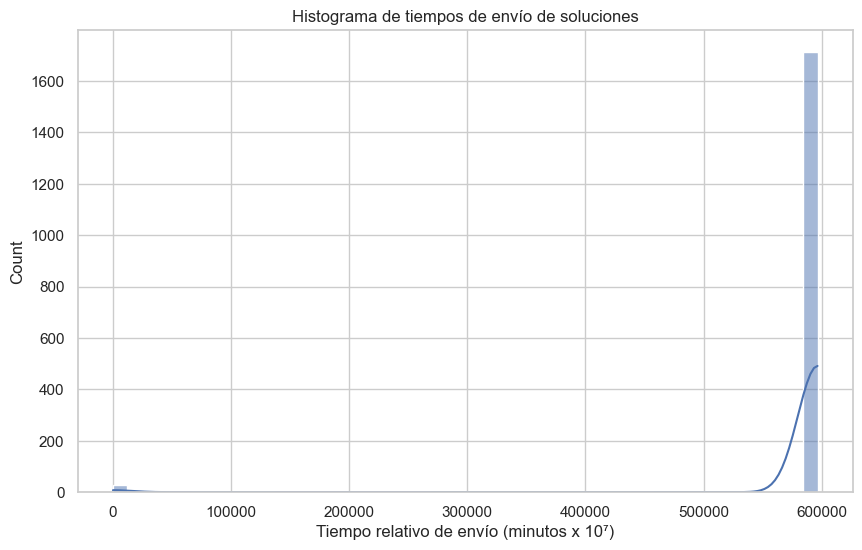

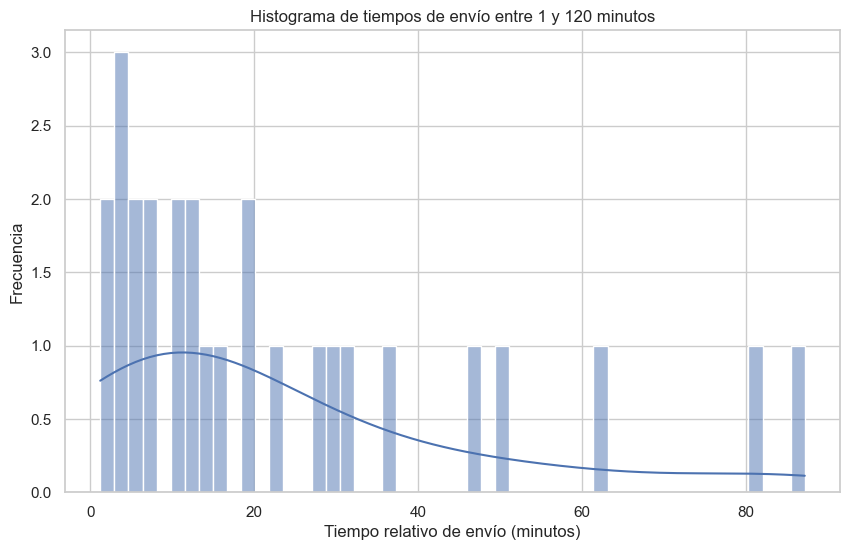

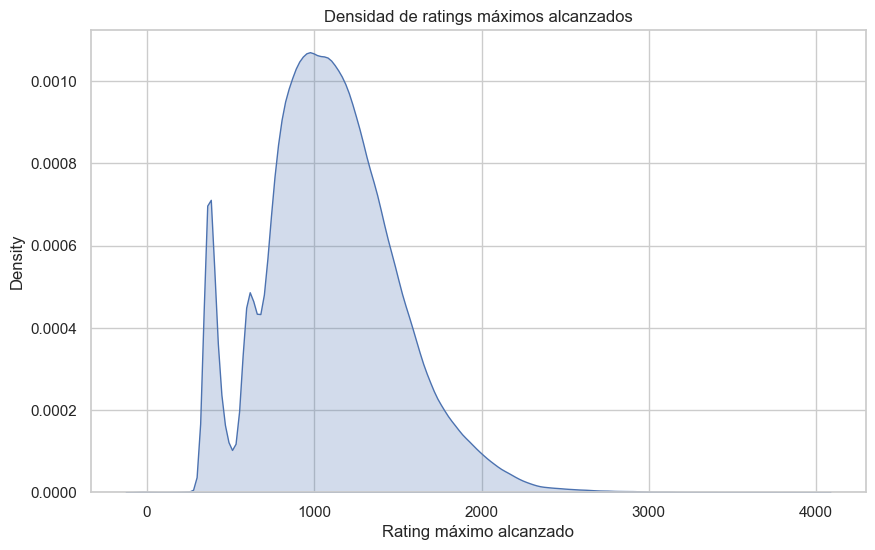

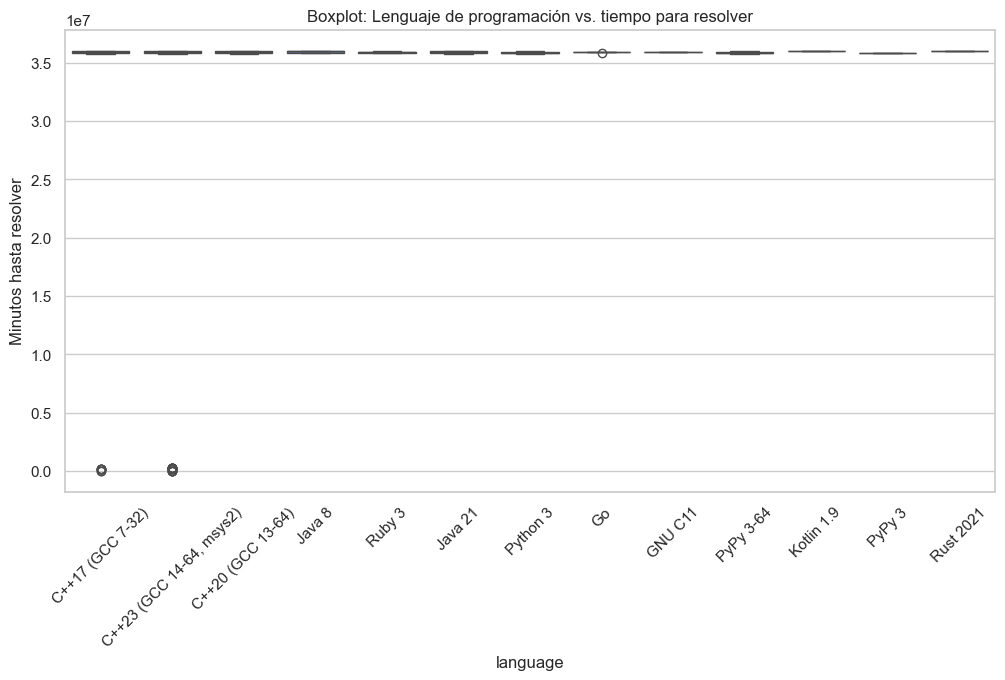

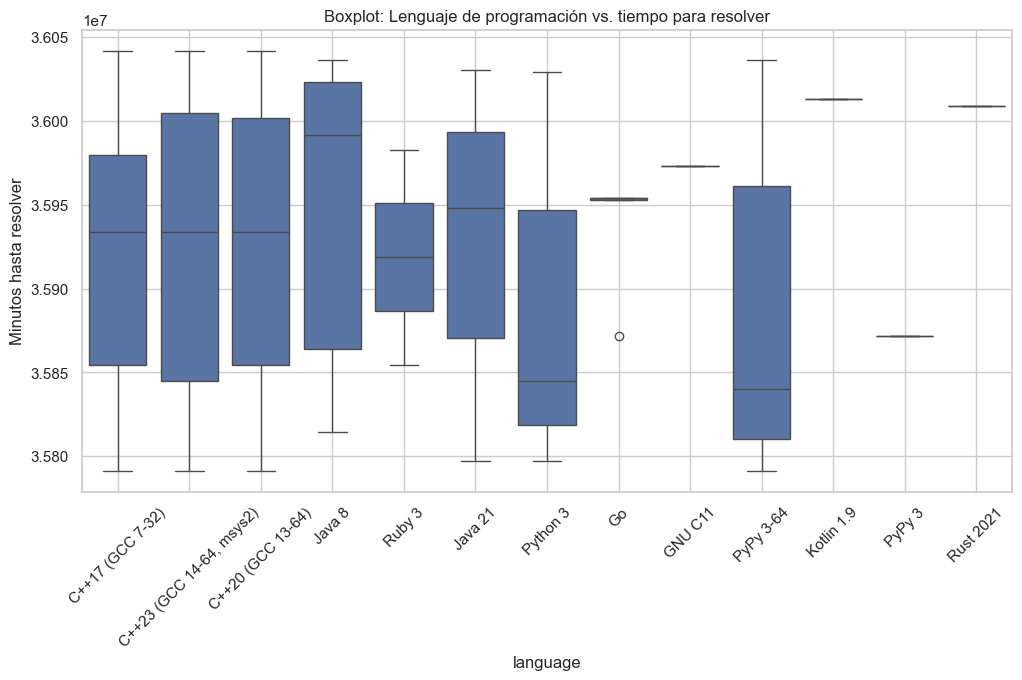

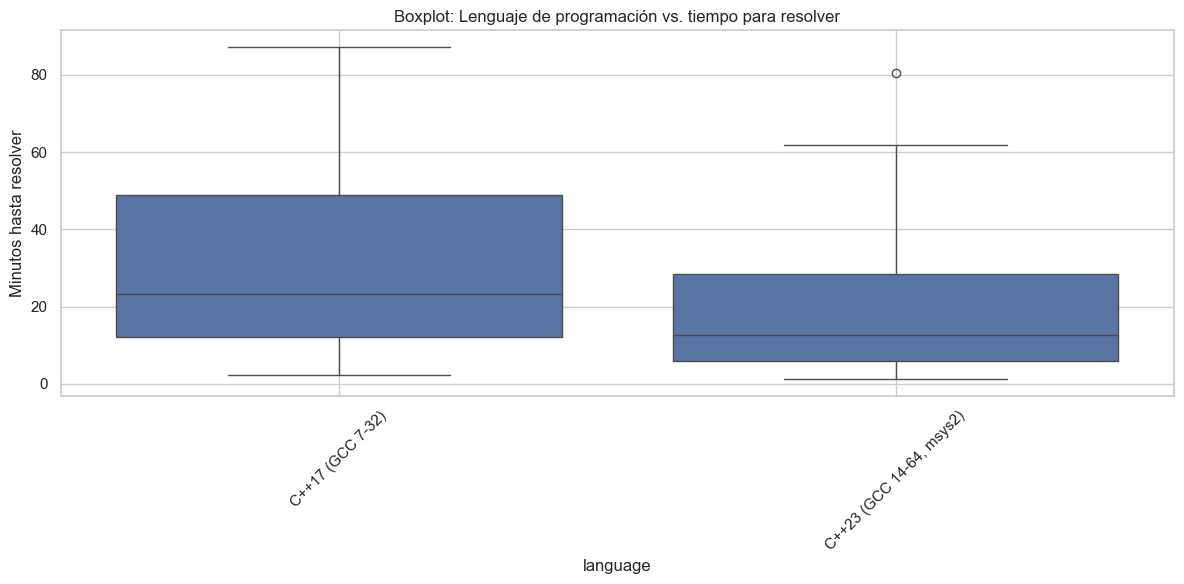

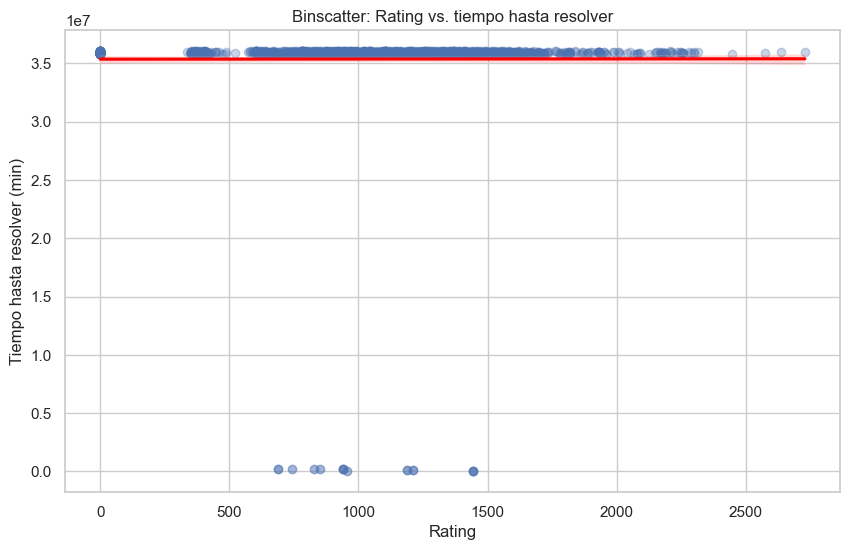

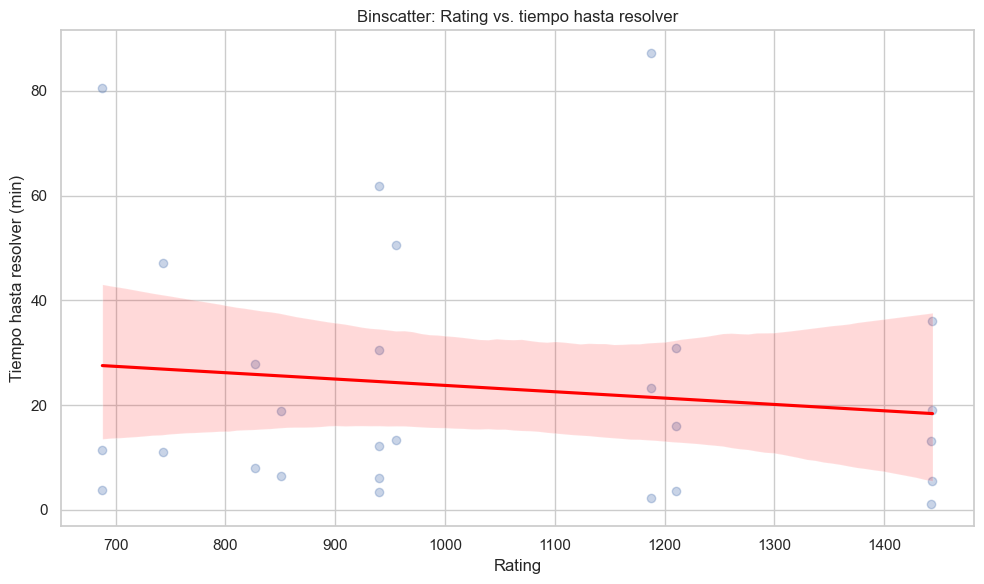

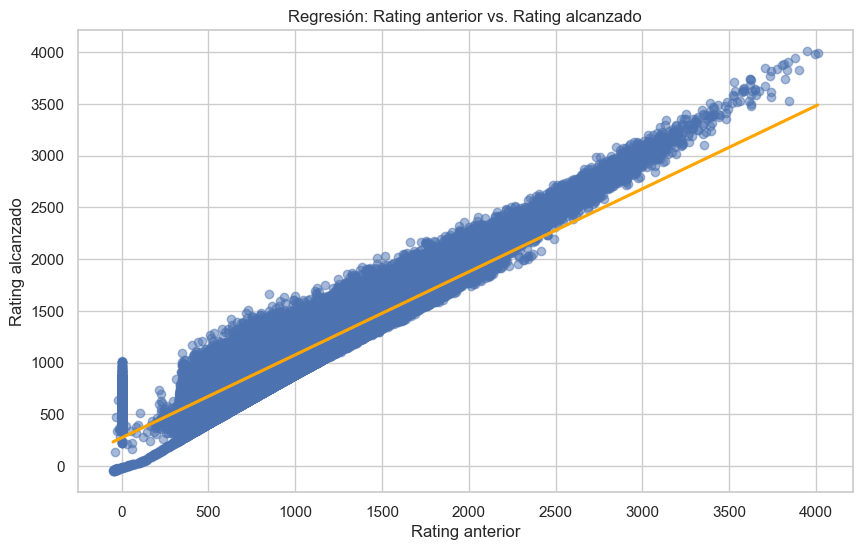

In [187]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Configuración
sns.set(style="whitegrid")

# 1. Histograma de tiempos de envío de soluciones
relative_cols = [col for col in df.columns if col.startswith('relative_time_')]
all_relative_times = pd.concat([df[col] for col in relative_cols]).dropna()


# Convertir a minutos
all_relative_times = df[[col for col in df.columns if col.startswith("relative_time_")]].values.flatten()
all_relative_times = pd.to_numeric(all_relative_times, errors='coerce')
all_relative_times = all_relative_times[~np.isnan(all_relative_times)]
all_relative_times_min = all_relative_times / 60


plt.figure(figsize=(10, 6))
sns.histplot(all_relative_times_min / 60, bins=50, kde=True)
plt.xlabel("Tiempo relativo de envío (minutos x 10⁷)")
plt.title("Histograma de tiempos de envío de soluciones")
plt.show()

# Filtrar entre 1 y 120 minutos
filtered_relative_times = all_relative_times_min[(all_relative_times_min > 1) & (all_relative_times_min < 120)]

# 1.1 Histograma de tiempos de envío de soluciones entre 1 y 120 minutos
plt.figure(figsize=(10, 6))
sns.histplot(filtered_relative_times, bins=50, kde=True)
plt.xlabel("Tiempo relativo de envío (minutos)")
plt.ylabel("Frecuencia")
plt.title("Histograma de tiempos de envío entre 1 y 120 minutos")
plt.grid(True)
plt.show()

# 2. Densidad de ratings máximos alcanzados
plt.figure(figsize=(10, 6))
sns.kdeplot(df[df['rating_achieved'].notna()]['rating_achieved'], fill=True)
plt.xlabel("Rating máximo alcanzado")
plt.title("Densidad de ratings máximos alcanzados")
plt.show()

# 3. Boxplots of language vs. time_to_answer
time_cols = [col for col in df.columns if col.startswith("time_to_answer_")]
lang_cols = [col for col in df.columns if col.endswith("_language")]

long_df = pd.DataFrame()
for time_col, lang_col in zip(time_cols, lang_cols):
    temp = df[[time_col, lang_col]].dropna()
    temp.columns = ['time_to_answer', 'language']
    temp['minutes'] = (temp['time_to_answer'] - df['contest_start_time'].iloc[0]).dt.total_seconds() / 60
    long_df = pd.concat([long_df, temp])

plt.figure(figsize=(12, 6))
sns.boxplot(x='language', y='minutes', data=long_df)
plt.xticks(rotation=45)
plt.ylabel("Minutos hasta resolver")
plt.title("Boxplot: Lenguaje de programación vs. tiempo para resolver")
plt.show()

# 3.1 Boxplots of language vs. time_to_answer (filtrando minutos > 0)
time_cols = [col for col in df.columns if col.startswith("time_to_answer_")]
lang_cols = [col for col in df.columns if col.endswith("_language")]

long_df = pd.DataFrame()

for time_col, lang_col in zip(time_cols, lang_cols):
    temp = df[[time_col, lang_col]].dropna()
    temp.columns = ['time_to_answer', 'language']
    temp['minutes'] = (temp['time_to_answer'] - df['contest_start_time'].iloc[0]).dt.total_seconds() / 60

    # Filtrar tiempos mayores a 0 minutos
    temp = temp[temp['minutes'] > 240000]

    long_df = pd.concat([long_df, temp])

plt.figure(figsize=(12, 6))
sns.boxplot(x='language', y='minutes', data=long_df)
plt.xticks(rotation=45)
plt.ylabel("Minutos hasta resolver")
plt.title("Boxplot: Lenguaje de programación vs. tiempo para resolver")
plt.grid(True)
plt.show()

# 3.2 Boxplots of language vs. time_to_answer (con filtro correcto de minutos > 0 y < 300)

time_cols = [col for col in df.columns if col.startswith("time_to_answer_")]
lang_cols = [col for col in df.columns if col.endswith("_language")]

long_df = pd.DataFrame()

for time_col, lang_col in zip(time_cols, lang_cols):
    temp = df[[time_col, lang_col, 'contest_start_time']].dropna()
    temp.columns = ['time_to_answer', 'language', 'contest_start_time']

    # Asegurarse de que ambos son tipo datetime
    temp['time_to_answer'] = pd.to_datetime(temp['time_to_answer'])
    temp['contest_start_time'] = pd.to_datetime(temp['contest_start_time'])

    # Calcular diferencia en minutos
    temp['minutes'] = (temp['time_to_answer'] - temp['contest_start_time']).dt.total_seconds() / 60

    # Filtrar tiempos válidos
    temp = temp[(temp['minutes'] > 0) & (temp['minutes'] < 300)]

    long_df = pd.concat([long_df, temp[['language', 'minutes']]])

plt.figure(figsize=(12, 6))
sns.boxplot(x='language', y='minutes', data=long_df)
plt.xticks(rotation=45)
plt.ylabel("Minutos hasta resolver")
plt.title("Boxplot: Lenguaje de programación vs. tiempo para resolver")
plt.grid(True)
plt.tight_layout()
plt.show()

# 4. Binscatter: Rating vs. tiempo hasta resolver
scatter_df = pd.DataFrame()
for col in time_cols:
    temp = df[[col, 'rating']].dropna()
    temp['time_minutes'] = (temp[col] - df['contest_start_time'].iloc[0]).dt.total_seconds() / 60
    scatter_df = pd.concat([scatter_df, temp[['rating', 'time_minutes']]])

plt.figure(figsize=(10, 6))
sns.regplot(data=scatter_df, x='rating', y='time_minutes', scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'})
plt.xlabel("Rating")
plt.ylabel("Tiempo hasta resolver (min)")
plt.title("Binscatter: Rating vs. tiempo hasta resolver")
plt.show()

# 4.1 Binscatter: Rating vs. tiempo hasta resolver (mayor a 0 minutos, menor a 5 horas)
scatter_df = pd.DataFrame()

for col in time_cols:
    temp = df[[col, 'contest_start_time', 'rating']].dropna()

    # Aseguramos que ambos sean datetime
    temp[col] = pd.to_datetime(temp[col])
    temp['contest_start_time'] = pd.to_datetime(temp['contest_start_time'])

    # Calcular diferencia en minutos correctamente
    temp['time_minutes'] = (temp[col] - temp['contest_start_time']).dt.total_seconds() / 60

    # Filtramos tiempos inválidos o exageradamente grandes
    temp = temp[(temp['time_minutes'] > 0) & (temp['time_minutes'] < 300)]  # Menos de 5 horas

    scatter_df = pd.concat([scatter_df, temp[['rating', 'time_minutes']]])

plt.figure(figsize=(10, 6))
sns.regplot(data=scatter_df, x='rating', y='time_minutes', scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'})
plt.xlabel("Rating")
plt.ylabel("Tiempo hasta resolver (min)")
plt.title("Binscatter: Rating vs. tiempo hasta resolver")
plt.grid(True)
plt.tight_layout()
plt.show()

# 5. Regression for rating vs rating_achieved 
reg_df = df[df['rating_achieved'].notna()][['rating', 'rating_achieved']].dropna()

plt.figure(figsize=(10, 6))
sns.regplot(data=reg_df, x='rating', y='rating_achieved', scatter_kws={'alpha': 0.5}, line_kws={'color': 'orange'})
plt.xlabel("Rating anterior")
plt.ylabel("Rating alcanzado")
plt.title("Regresión: Rating anterior vs. Rating alcanzado")
plt.show()

In [ ]:
# Análisis Descriptivo Visual con Interpretaciones

# 1. Histograma de tiempos de envío de soluciones (sin filtrar)
# Este gráfico muestra la distribución general del tiempo relativo en el que los usuarios envían sus soluciones. 
# La curva indica que en el extremo izquierdo (cerca de cero) hay una pequena curva, lo que sugiere que algunos participantes envían sus respuestas rápidamente después de iniciado el concurso. 
# Sin embargo, hay una larga cola hacia la derecha, lo que indica que la gran mayorí de envíos tardan considerablemente más.

# 1.1 Histograma de tiempos entre 1 y 120 minutos  
# Al enfocar el análisis en envíos entre 1 y 120 minutos, se observa una curva más suave y detallada. 
# La mayoría de los envíos ocurren en los primeros minutos del concurso, con un descenso progresivo. 
# Esto refleja que los usuarios que conocen la respuesta o tienen mayor habilidad suelen responder temprano.

# 2. Densidad de ratings máximos alcanzados
# Este gráfico muestra la distribución de los ratings máximos alcanzados. 
# La curva tiene dos picos, uno cerca a 400 y otro más pronunciado en 1000, lo que indica que la mayoría de usuarios tienden a concentrarse en un cierto rango de rating. 
# Esto podría reflejar el nivel predominante de experiencia en la plataforma.

# 3. Boxplot: Lenguaje de programación vs. tiempo para resolver 
# El boxplot permite comparar cuánto tiempo demoran los usuarios en resolver dependiendo del lenguaje de programación. 
# Se observan algunos outliers en 0 para lenguajes como C++17 y C++23.

# 3.1 Boxplot: Lenguaje de programación vs. tiempo para resolver (filtrando minutos > 0)
# Se excluyeron lenguajes con tiempos anómalos (como C++17 y C++23 con tiempos de 0).
# Algunos lenguajes como Java 8 muestran una mayor concentración de respuestas rápidas, mientras que otros pueden tener mayor variabilidad o valores atípicos. 

# 3.2 Boxplot: Lenguaje de programación vs. tiempo para resolver (con filtro correcto de minutos > 0 y < 300)
# Sólo se incluyen tiempos de 0 a 300 minutos.
# Se tienen sólo a los lenguajes de C++17 y C++23, ambos con mayoría de respuestas entre 10 y 50 minutos.

# 4. Binscatter: Rating vs. tiempo hasta resolver (sin filtrar)
# Esta primera versión muestra una baja concentración de puntos en la parte baja del eje Y (tiempo cercano a 0), lo que hace difícil identificar una relación clara. 
# La línea de regresión sugiere una leve tendencia: los usuarios con mayor rating podrían demorar un poco menos, pero hay mucha dispersión.

# 4.1 Binscatter: Rating vs. tiempo hasta resolver (filtrado entre 1 y 300 minutos)
# Una vez filtrados los valores extremos, se observa con más claridad una relación negativa débil: los usuarios con mayor rating tienden a resolver en menos tiempo. 
# Aunque la dispersión sigue siendo amplia, la pendiente negativa de la regresión respalda esta idea.

# 5. Regresión: Rating anterior vs. Rating alcanzado
# Este scatterplot con línea de regresión muestra una clara relación positiva: los usuarios que tenían un rating alto suelen alcanzar también ratings altos después del concurso. 
# Aunque hay cierta variabilidad, la tendencia sugiere consistencia en el desempeño de los usuarios más experimentados.